# Data Science Lab: Lab 3

All the data sets you will need for this lab are in Canvas/Files/Data Sets, or at the given link.

**Submit**:

A read-only link to your colab notebook, executed and saved (so that we can run it, but don't necessarily have to, to see your results).

For any questions that require written explanation, please use Markdown - it is a lot easier for us to read than comments in the code.

**If you used any AI help, please describe how you used it and what you used.**

# Goals of this Lab

1. Playing with logistic regression
2. More experience with L1 and L2 regularization.
3. More experience with cross validation.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
%matplotlib inline


# Problem 1

1. Plot the data in ``Lab3_PS1``
2. Fit a simple logistic regression. Plot the data and the decision boundary.
3. Overfit the data: augment the X matrix by adding all monomials up to degree 4. How many features do you now have?
4. Fit the data, and plot the **non-linear** decision boundary that results.


In [2]:
# Load in the data

data = np.load("Lab3_P1.npz")
X = data["X"]
y = data["y"]

# Shape of data
print(X.shape)
print(y.shape)

# Look at what the data looks like
print (X[:5])
print (y[:5])

(20, 2)
(20,)
[[ 0.78560542 -0.80355338]
 [ 0.11907566 -0.10400145]
 [-0.27659435 -0.55433942]
 [-0.67927633 -0.25716803]
 [ 0.32105655  0.71705366]]
[0. 0. 0. 0. 0.]


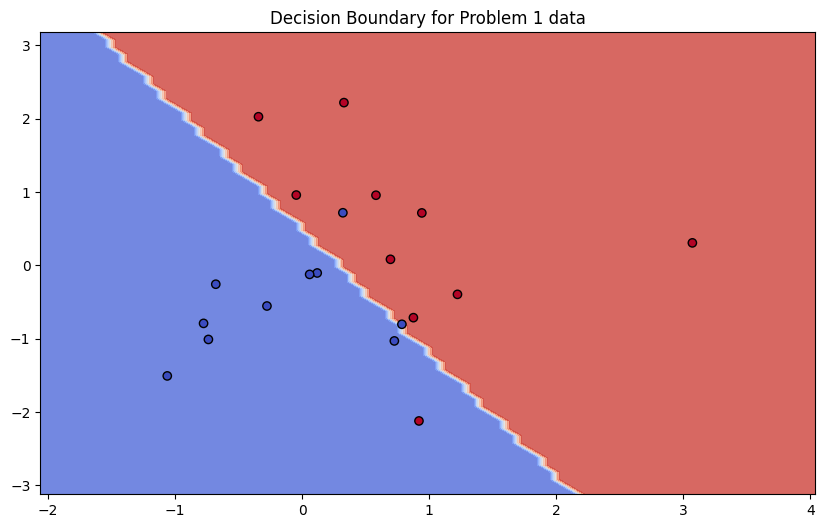

In [3]:
# Fitting logistic regresision and plotting decision boundary

model = LogisticRegression()
model.fit(X, y)
# Plotting decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

 # Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                    np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.title(f'Decision Boundary for Problem 1 data')
plt.show()

In [4]:
# Overfitting by addding all monmomials to degree 4
X_orig = data["X"].copy()          # shape (n,2)
y = data["y"]

# augment training data exactly once
for i in range(2, 5):
    X = np.hstack((X, (X_orig[:, 0] ** i).reshape(-1, 1), (X_orig[:, 1] ** i).reshape(-1, 1)))

print (f"X now has {X.shape[1]} features")


X now has 8 features


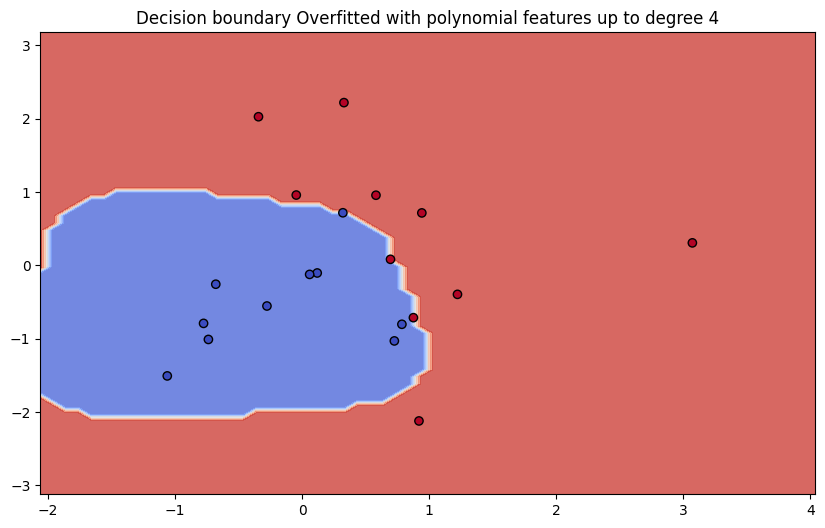

In [5]:
# Fitting the data again
model_poly = LogisticRegression()
model_poly.fit(X, y)

# build mesh on the original two coordinates
x_min, x_max = X_orig[:, 0].min() - 1, X_orig[:, 0].max() + 1
y_min, y_max = X_orig[:, 1].min() - 1, X_orig[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]

grid_aug = grid.copy()
for i in range(2, 5):
    grid_aug = np.hstack((grid_aug,
                          (grid[:, 0] ** i).reshape(-1, 1),
                          (grid[:, 1] ** i).reshape(-1, 1)))

assert grid_aug.shape[1] == model_poly.n_features_in_

Z = model_poly.predict(grid_aug).reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_orig[:, 0], X_orig[:, 1], c=y,
            cmap=plt.cm.coolwarm, edgecolor='k')
plt.title('Decision boundary Overfitted with polynomial features up to degree 4')
plt.show()

# Problem 2

1. Load the data ``Lab3_P2.npz``. This is additional testing data for the previous problem.
2. Compute the training and testing error (fraction wrong) for the simple model and the extended (polynomial) model.
3. We learned about the log likelihood function and how its negative can be thought of as the loss function for logistic regression. This is called log_loss and you can import it from sklearn.metrics. Use that to compute the training and testing loss for the simple model and the extended model.
4. For the above problem, you cannot use ``model.predict()``. Figure out what (related) method you need to use, and explain how it is different from ``model.predict()``.

In [6]:
# Load the data
test_data = np.load("Lab3_P2.npz")
X_more = test_data["Xmore"]
y_more = test_data["ymore"]

# Look at data shape
print (X_more.shape)
print (y_more.shape)

# Look at data examples
print (X_more[:5])
print (y_more[:5])


(200, 2)
(200,)
[[ 0.28449683  0.69916366]
 [-1.21443438 -0.72865476]
 [-1.26605679 -0.74841661]
 [-0.76142354  0.11001596]
 [ 1.23338949  0.23876472]]
[0. 0. 0. 0. 0.]


In [ ]:
print ("Train Error", 1-model.score(X_orig, y))
print ("Test Error", 1-model.score(X_more, y_more))

Train Error 0.15000000000000002
Test Accuracy: 0.74
Test Error 0.26


In [ ]:
# Create polynomial model 
X_orig_test = test_data["Xmore"].copy()
y_orig_test = test_data["ymore"]

# augment data
for i in range(2, 5):
    X_more = np.hstack((X_more, (X_orig_test[:, 0] ** i).reshape(-1, 1), (X_orig_test[:, 1] ** i).reshape(-1, 1)))

print ("Train Error",  1- model_poly.score(X, y))
print ("Test Error", 1-model_poly.score(X_more, y_more))


Train Error 0.09999999999999998
Test Accuracy: 0.635
Test Error 0.365


In [9]:
# Log liklihood function for logistic regression simple model
from sklearn.metrics import log_loss

y_prob_train = model.predict_proba(X_orig)
log_likelihood_train = log_loss(y, y_prob_train)
print("Log Likelihood (Train):", log_likelihood_train)

y_prob_test = model.predict_proba(X_orig_test)
log_likelihood = log_loss(y_more, y_prob_test)
#print(y_prob_test.shape, y_prob_test[:5])
print("Log Likelihood (Test):", log_likelihood)
#print("Accuracy:", model.score(X_orig_test, y_more))


Log Likelihood (Train): 0.4149091842063165
Log Likelihood (Test): 0.5398704958052388


In [10]:
# Log liklihood function for logistic regression polynomial model
y_prob_train_poly = model_poly.predict_proba(X)
log_likelihood_train = log_loss(y, y_prob_train_poly)
print("Log Likelihood (Train):", log_likelihood_train)

y_prob_test_poly = model_poly.predict_proba(X_more)
log_likelihood = log_loss(y_more, y_prob_test_poly)
# print(y_prob_test.shape, y_prob_test[:5])
print("Log Likelihood (Test):", log_likelihood)

Log Likelihood (Train): 0.24489710129232098
Log Likelihood (Test): 1.6938870067994083


The predict_proba function in the sklearn library is used to predict the actual probablity of each class given our input. Then the log loss function quanitifies the loss based on the logits. The predict_prba function differs frm the predict function in taht the predict function will output the actual predicted class while the predict_proba will predict the proabblity for each class. 

# Problem 3

1. Load the data in ``Lab3_P3.npz``. How many training and testing data points do you have, and how many features?
2. Fit a logistic regression to the data. Do you think you are overfitting or underfitting? Explain and back up your answer with computations.
3. Use cross validation to find a good L2 regularizer. Try to find the best test accuracy.
4. Use cross validation to find a good L1 regularizer. Try to find the best test accuracy. **Note: If you try to run something like:
```
LogisticRegression(penalty='l1', C=1, max_iter=1000)
```
you will get a syntax error (which you will not get when you use similar code for L2 regularization). Read the documentation from sklearn to figure out how to fix this (hint: something to do with ``saga``...)

**Note: For CV, you may want to experiment with different valus of ``k``**.

In [32]:
data_p3 = np.load("Lab3_P3.npz")
print (data_p3)

NpzFile 'Lab3_P3.npz' with keys: X_train, X_test, y_train, y_test


In [35]:
X_train = data_p3["X_train"]
X_test = data_p3["X_test"]
y_train = data_p3["y_train"]
y_test = data_p3["y_test"]

print (X_train.shape)
print (y_train.shape)

print (X_test.shape)
print (y_test.shape)

print (f"Total number of features: {X_train.shape[1]}")
print(f"Number of training data points: {X_train.shape[0]}")
print(f"Number of test data points: {X_test.shape[0]}")

(35, 18)
(35,)
(15, 18)
(15,)
Total number of features: 18
Number of training data points: 35
Number of test data points: 15


In [39]:
# Fitting logistic regresision onto the  data
model = LogisticRegression()
model.fit(X_train, y_train)
ll_train = log_loss(y_train, model.predict_proba(X_train))
print("Log Loss (Train):", ll_train)
ll_test = log_loss(y_test, model.predict_proba(X_test))
print("Log Loss (Test):", ll_test)
print ("Accuracy:", model.score(X_test, y_test))

Log Loss (Train): 0.19378494810183702
Log Loss (Test): 1.146895839748456
Accuracy: 0.4666666666666667


Yes there is a large and substantial diffeence in the train error and the test error, specifically the test error is much larger than the train error which indicates that the model is overfitting on the train data. As seen with the computed log loss values where the trina is much cloaser to 0, indicaitng somewhat good performance while the test error is over 1, indicating lots of innacuracy in the predictions. 

In [62]:
# Cross validation for L2 regularizer
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

C_values = [0.01, 0.1, 1, 10, 100]
cv_scores = []

for C in C_values:
    fold_scores = []
    for train_idx, test_idx in kf.split(X_more):
        X_tr, X_test = X_more[train_idx], X_more[test_idx]
        y_tr, y_test = y_orig[train_idx], y_orig[test_idx]

        model = LogisticRegression(l1_ratio=0, C=C, random_state=42, max_iter=1000)   # L2 regularizer
        model.fit(X_tr, y_tr)
        fold_scores.append(log_loss(y_test, model.predict_proba(X_test)))

    mean_score = np.mean(fold_scores)
    cv_scores.append(mean_score)
    print(f"C={C}, mean CV log loss = {mean_score:.4f}")

C=0.01, mean CV log loss = 0.5376
C=0.1, mean CV log loss = 0.5265
C=1, mean CV log loss = 0.5508
C=10, mean CV log loss = 0.5661
C=100, mean CV log loss = 0.5680


In [60]:
# Cross validation for L1 regularizer 
kf = KFold(n_splits=2, shuffle=True, random_state=42)

C_values = [0.01, 0.1, 1, 10, 100]
cv_scores_l1 = []

for C in C_values:
    fold_losses = []
    for train_idx, val_idx in kf.split(X_more):
        X_tr, X_val = X_more[train_idx], X_more[val_idx]
        y_tr, y_val = y_orig[train_idx], y_orig[val_idx]

        model = LogisticRegression(l1_ratio=1, solver='saga', C=C, random_state=42, max_iter=8000)
        model.fit(X_tr, y_tr)
        fold_losses.append(log_loss(y_val, model.predict_proba(X_val)))

    mean_loss = np.mean(fold_losses)
    cv_scores_l1.append(mean_loss)
    print(f"C={C}, mean CV log loss (L1) = {mean_loss:.4f}")

C=0.01, mean CV log loss (L1) = 0.6782
C=0.1, mean CV log loss (L1) = 0.5387
C=1, mean CV log loss (L1) = 0.5206
C=10, mean CV log loss (L1) = 0.5238
C=100, mean CV log loss (L1) = 0.5248


# Problem 4

In class we used random forests and bagging for CIFAR-10. Use similar techniques to get the best solution you can find for the MNIST dataset. This will require you to tune the parameters of Random Forests and Bagging. I recommend you use Random Forests from sklearn, and Boosting from XGBoost.

You will first need to load MNIST, using code that we saw in previous notebooks in this class.

In [93]:
import numpy as np
from torchvision import datasets, transforms

# Custom transform to convert tensor to numpy array and remove channel dimension
class ToNumpyNoChannel:
    def __call__(self, tensor):
        return tensor.squeeze(0).numpy()  # Remove channel dimension (C, H, W -> H, W)

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts PIL image to PyTorch tensor
    transforms.Normalize(mean=(0.5,), std=(0.5,)),  # Normalize to [-1, 1]
    ToNumpyNoChannel()  # Convert tensor to numpy array and remove channel dimension
])

# Load datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Access data and labels as NumPy arrays
X_train = np.array([train_dataset[i][0] for i in range(len(train_dataset))])  # Features
y_train = np.array([train_dataset[i][1] for i in range(len(train_dataset))])  # Labels
X_test = np.array([test_dataset[i][0] for i in range(len(test_dataset))])    # Features
y_test = np.array([test_dataset[i][1] for i in range(len(test_dataset))])    # Labels

In [94]:
import time
from sklearn.utils import check_random_state

# Do a random permutation of the data
t0 = time.time()
random_state = check_random_state(0)
permutation = random_state.permutation(X_train.shape[0])
X_train = X_train[permutation]
y_train = y_train[permutation]
permutation = random_state.permutation(X_test.shape[0])
X_test = X_test[permutation]
y_test = y_test[permutation]

# Print dimensions
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of X_test: (10000, 28, 28)
Shape of y_test: (10000,)


In [95]:
# Flatten images so we can train
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (60000, 784)
Shape of X_test: (10000, 784)


In [96]:
# Pick a subset of data points
train_samples = 5000
test_samples = 1000

X_train = X_train[:train_samples]
y_train = y_train[:train_samples]
X_test = X_test[:test_samples]
y_test = y_test[:test_samples]
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((5000, 784), (5000,), (1000, 784), (1000,))

In [97]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

estimators = [10, 50, 100, 200]
depth = 15
training_scores = []
testing_scores = []

for n in estimators:
    print(f"Training Random Forest with {n} estimators (max depth={depth})...")

    rf = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    train_score = rf.score(X_train, y_train)
    test_score = rf.score(X_test, y_test)
    training_scores.append(train_score)
    testing_scores.append(test_score)

    print(f"  Training accuracy: {train_score:.4f}")
    print(f"  Testing accuracy: {test_score:.4f}")
    print()

print("Random Forest results:")
for i, n in enumerate(estimators):
    print(f"k={n}: Train={training_scores[i]:.4f}, Test={testing_scores[i]:.4f}")

Training Random Forest with 10 estimators (max depth=15)...
  Training accuracy: 0.9988
  Testing accuracy: 0.8930

Training Random Forest with 50 estimators (max depth=15)...
  Training accuracy: 0.9998
  Testing accuracy: 0.9460

Training Random Forest with 100 estimators (max depth=15)...
  Training accuracy: 0.9998
  Testing accuracy: 0.9520

Training Random Forest with 200 estimators (max depth=15)...
  Training accuracy: 0.9998
  Testing accuracy: 0.9530

Random Forest results:
k=10: Train=0.9988, Test=0.8930
k=50: Train=0.9998, Test=0.9460
k=100: Train=0.9998, Test=0.9520
k=200: Train=0.9998, Test=0.9530


In [98]:
import xgboost as xgb

estimators_xgb = [10, 50, 100, 200]
depth_xgb = 5
training_scores_xgb = []
testing_scores_xgb = []

for n in estimators:
    print(f"Training XGBoost with {n} estimators (max depth={depth_xgb})...")
    xgb_model = xgb.XGBClassifier(n_estimators=n, max_depth=depth_xgb,
                                  random_state=42,
                                  n_jobs=-1,
                                  verbosity=0)
    xgb_model.fit(X_train, y_train)

    train_score = xgb_model.score(X_train, y_train)
    test_score = xgb_model.score(X_test, y_test)
    training_scores_xgb.append(train_score)
    testing_scores_xgb.append(test_score)

    print(f"  Training accuracy: {train_score:.4f}")
    print(f"  Testing accuracy: {test_score:.4f}")
    print()

print("XGBoost Results:")
for i, n_est in enumerate(estimators_xgb):
    print(f"k={n}: Train={training_scores_xgb[i]:.4f}, Test={testing_scores_xgb[i]:.4f}")

Training XGBoost with 10 estimators (max depth=5)...
  Training accuracy: 0.9834
  Testing accuracy: 0.9170

Training XGBoost with 50 estimators (max depth=5)...
  Training accuracy: 1.0000
  Testing accuracy: 0.9510

Training XGBoost with 100 estimators (max depth=5)...
  Training accuracy: 1.0000
  Testing accuracy: 0.9550

Training XGBoost with 200 estimators (max depth=5)...
  Training accuracy: 1.0000
  Testing accuracy: 0.9570

XGBoost Results:
k=200: Train=0.9834, Test=0.9170
k=200: Train=1.0000, Test=0.9510
k=200: Train=1.0000, Test=0.9550
k=200: Train=1.0000, Test=0.9570


# Problem 6 (Optional)

The following is a logistic regression problem using a real data set, made available by the authors of the book ``Applied Regression and Muiltilevel Modeling'' by Gelman and Hill.

The point of this problem: besides gaining more experience and learning a few more things about logistic regression, my goal is to make clear that there are interesting/important datasets everywhere... and we should not shy away from finding them and using them!

Download the data from the book, which you can find here http://www.stat.columbia.edu/~gelman/arm/software/. In particular, we are interested in the **arsenic** data set. The file **wells.dat** contains data on 3,020 households in Bangladesh. For each family, the natural arsenic level of each well was measured. In addition, the distance to the nearest safest well was measured. Each family is also described by a feature that relates to their community involvement, and a feature that gives the education level of the head of household. We are interested in building a model that predicts whether the family decided to switch wells or not, based on being informed of the level of arsenic in the well. Thus the "label" for this problem is the binary vector that is the first column of the dataset, labeled "switch."

1. Fit a logistic regression model using only an offset term and the distance to the nearest safe well.
2. Plot your answer: that is, plot the probability of switching wells as a function of the distance to the nearest safe well.
3. Interpreting logistic regression coefficients: In linear regression, there is an obvious interpretation for the coefficients of linear regression (e.g., $\beta_{sf}$ is the additional value of a house per additional square foot). This is not so clear in logistic regression because of the non-linearity of the soft-max function. One way to interpret a particular coefficient is using the "rule-of-4". This can be derived by simple calculus. It says: for any coefficient $w_i$ of the logistic regression, $w_i/4$ is the *maximum possible effect* on the probability our model predicts "1" that can result from a change in $x_i$ by 1 unit. We can use it here, for example, with analyzing the maximum possible change in the probability of changing wells, correlated with an additional 100 meters of distance.
4. Now solve a logistic regression incorporating the constant term, the distance and also arsenic levels. Report the coefficients
5. Next we want to answer the question of which factor is more significant, distance, or arsenic levels? This is not a well specified question, since these two features have different units. One natural choice is to ask if after normalizing by the respective standard deviations of each feature, if moving one unit in one (normalized) feature predicts a larger change in probability of switching wells, than moving one unit in the other (also normalized) feature. Use this reasoning to answer the question.
6. Now consider all the features in the data set. Also consider adding interaction terms among all features that have a large main effect. Use cross validation to build the best model you can (using your training set only), and then report the test error of your best model. (Note that since you have essentially unlimited access to your test set, this opens the door for massive overfitting. In contrast, Kaggle competitions try to mollify this by giving you only limited access to the test set.)
7. (Optional) Now also play around with $\ell_1$ and $\ell_2$ regularization, and try to build the most accurate model you can (accuracy computed on the test data).

# Problem 5 (Optional)

Try to run logistic regression from sklearn for the MNIST data.